## Modelo de Regresión con Random Forest

Entrenamiento de un modelo Random Forest para predecir las ganancias totales diarias usando los datos de entrenamiento, validación y prueba.

#### Librerías necesarias

In [8]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error, r2_score, mean_squared_error
import matplotlib.pyplot as plt

#### Carga del dataset.

In [9]:
df_train = pd.read_csv('../../output/regresion/data_train_regresion.csv', encoding='ISO-8859-1')
df_validation = pd.read_csv('../../output/regresion/data_validation_regresion.csv', encoding='ISO-8859-1')
df_test = pd.read_csv('../../output/regresion/data_test_regresion.csv', encoding='ISO-8859-1')

print(f"Train: {df_train.shape}")
print(f"Validation: {df_validation.shape}")
print(f"Test: {df_test.shape}")
print(f"\nColumnas: {df_train.columns.tolist()}")

Train: (220, 9)
Validation: (55, 9)
Test: (17, 9)

Columnas: ['GananciasTotales', 'DiaMes', 'Lag_1_Ventas', 'DiaSemana_Domingo', 'DiaSemana_Jueves', 'DiaSemana_Lunes', 'DiaSemana_Martes', 'DiaSemana_Miercoles', 'DiaSemana_Viernes']


#### Preparación de features y target.

In [10]:
X_train = df_train.drop('GananciasTotales', axis=1)
y_train = df_train['GananciasTotales'].values

X_validation = df_validation.drop('GananciasTotales', axis=1)
y_validation = df_validation['GananciasTotales'].values

X_test = df_test.drop('GananciasTotales', axis=1)
y_test = df_test['GananciasTotales'].values

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"\nPrimeras 5 filas de X_train:")
print(X_train.head())

X_train shape: (220, 8)
y_train shape: (220,)

Primeras 5 filas de X_train:
   DiaMes  Lag_1_Ventas  DiaSemana_Domingo  DiaSemana_Jueves  DiaSemana_Lunes  \
0       2      31052.61                0.0               1.0              0.0   
1       3      26292.13                0.0               0.0              0.0   
2       5      25490.33                1.0               0.0              0.0   
3       6      23445.96                0.0               0.0              1.0   
4       7      36394.80                0.0               0.0              0.0   

   DiaSemana_Martes  DiaSemana_Miercoles  DiaSemana_Viernes  
0               0.0                  0.0                0.0  
1               0.0                  0.0                1.0  
2               0.0                  0.0                0.0  
3               0.0                  0.0                0.0  
4               1.0                  0.0                0.0  


#### Entrenamiento del modelo Random Forest.

In [11]:
model = RandomForestRegressor(
  n_estimators=100,
  max_depth=10,
  min_samples_split=5,
  min_samples_leaf=2,
  random_state=42,
  n_jobs=-1
)

model.fit(X_train, y_train)

print("Modelo Random Forest entrenado correctamente")

Modelo Random Forest entrenado correctamente


#### Evaluación del modelo.

In [12]:
y_train_pred = model.predict(X_train)
y_validation_pred = model.predict(X_validation)
y_test_pred = model.predict(X_test)

def evaluar_modelo(y_true, y_pred, nombre_conjunto):
  mape = mean_absolute_percentage_error(y_true, y_pred) * 100
  r2 = r2_score(y_true, y_pred) * 100
  rmse = np.sqrt(mean_squared_error(y_true, y_pred))
  
  print(f"\n{nombre_conjunto}:")
  print(f"  MAPE:  {mape:.2f}%")
  print(f"  R²:    {r2:.2f}%")
  print(f"  RMSE:  {rmse:.2f}")

evaluar_modelo(y_train, y_train_pred, "ENTRENAMIENTO")
evaluar_modelo(y_validation, y_validation_pred, "VALIDACIÓN")
evaluar_modelo(y_test, y_test_pred, "TEST")


ENTRENAMIENTO:
  MAPE:  15.88%
  R²:    79.21%
  RMSE:  2614.58

VALIDACIÓN:
  MAPE:  23.08%
  R²:    -47.67%
  RMSE:  7758.07

TEST:
  MAPE:  26.75%
  R²:    -134.12%
  RMSE:  9002.90


#### Importancia de features.


Importancia de features:
            feature  importance
       Lag_1_Ventas    0.414465
  DiaSemana_Domingo    0.336336
             DiaMes    0.166767
  DiaSemana_Viernes    0.025265
DiaSemana_Miercoles    0.023090
   DiaSemana_Jueves    0.018527
    DiaSemana_Lunes    0.008333
   DiaSemana_Martes    0.007217


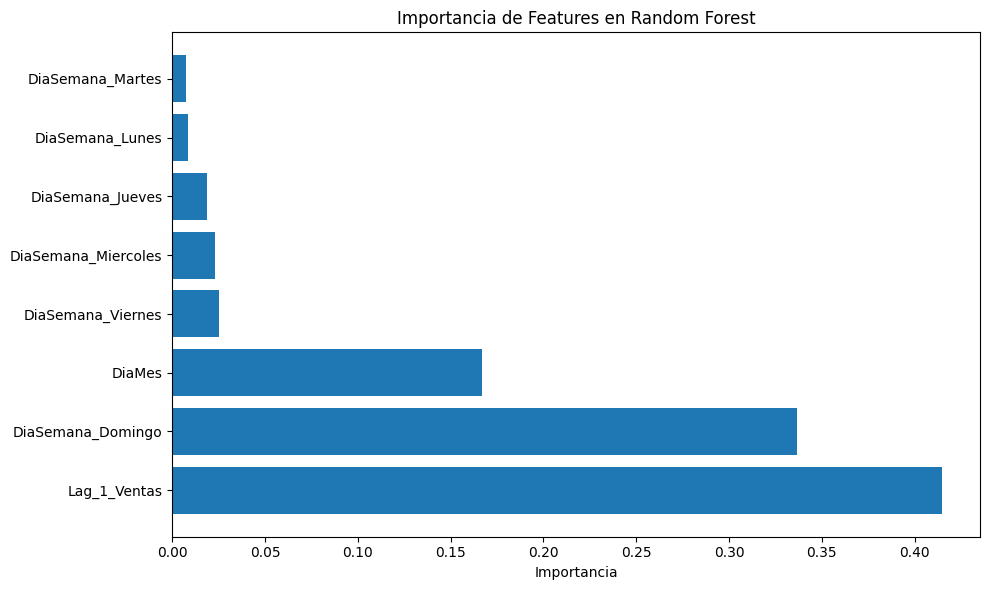

In [13]:
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({
  'feature': X_train.columns,
  'importance': importances
}).sort_values('importance', ascending=False)

print("\nImportancia de features:")
print(feature_importance_df.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.xlabel('Importancia')
plt.title('Importancia de Features en Random Forest')
plt.tight_layout()
plt.show()

#### Visualización de predicciones vs realidad.

Vemos que las predicciones del modelo siguen los patrones generales de las ganancias totales diarias, pero en un rango inferior de ganancias totales. Lo que indica que predice bien las tendencias pero subestima los valores absolutos. Esto se debe a que las ganancias totales diarias en los meses del conjunto de validación y test son mayores.

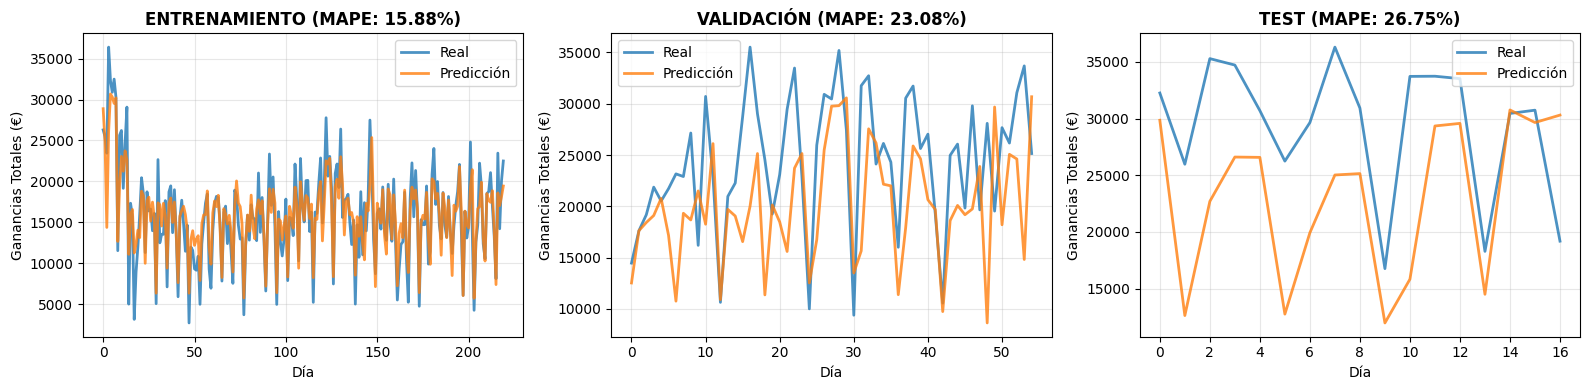

In [14]:
mape_train = mean_absolute_percentage_error(y_train, y_train_pred) * 100
mape_validation = mean_absolute_percentage_error(y_validation, y_validation_pred) * 100
mape_test = mean_absolute_percentage_error(y_test, y_test_pred) * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(y_train, label='Real', linewidth=2, alpha=0.8)
axes[0].plot(y_train_pred, label='Predicción', linewidth=2, alpha=0.8)
axes[0].set_title(f'ENTRENAMIENTO (MAPE: {mape_train:.2f}%)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Día')
axes[0].set_ylabel('Ganancias Totales (€)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(y_validation, label='Real', linewidth=2, alpha=0.8)
axes[1].plot(y_validation_pred, label='Predicción', linewidth=2, alpha=0.8)
axes[1].set_title(f'VALIDACIÓN (MAPE: {mape_validation:.2f}%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Día')
axes[1].set_ylabel('Ganancias Totales (€)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(y_test, label='Real', linewidth=2, alpha=0.8)
axes[2].plot(y_test_pred, label='Predicción', linewidth=2, alpha=0.8)
axes[2].set_title(f'TEST (MAPE: {mape_test:.2f}%)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Día')
axes[2].set_ylabel('Ganancias Totales (€)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()